# What makes a Movie Popular?

## Analyzing the Relationship Between Genre, Ratings, and Audience Interest.

This project analyzes IMDb movie data to explore what factors are asssociated with movie popularity.

This project examines movie ratings, number of audience votes, genre, runtime, and realease period to identify patterns in the types of movies that receive high ratings and strong audience engagement.



## Research Questions

1. **Is there a relationship between a movie's IMDb rating and the number of audience votes it receives?**

2. **Which movie genres receive the most audience interest?**

3. **Which genres have the highest average IMDb ratings?**

4. **Has the average runtime of movies changed over time?**

5. **Which decades produced the highest-rated movies?**

6. **Do highly rated movies necessarily receive a large number of audience votes?**

## Data Source

The data for this project comes from the **IMDb Non-Commercial Datasets**.

Two IMDb datasets were used:

- `title.basics.tsv.gz` — contains information about movie titles, release years, runtime, and genres.
- `title.ratings.tsv` — contains IMDb average ratings and the number of votes for each title.

The datasets were combined using IMDb's unique title identifier (`tconst`).

For this analysis, the dataset was limited to titles classified as **movies**.

The IMDb datasets are updated regularly, so the results of this analysis represent the data available at the time the project was completed.

## Import Libraries

The analysis uses Python and the following libraries:

- **Pandas** for loading, cleaning, and analyzing the data
- **NumPy** for numerical calculations
- **Matplotlib** for creating visualizations


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load the Data

The IMDb datasets are loaded into Pandas DataFrames.

The `title.basics` dataset provides movie information such as title, release year, runtime, and genre.

The `title.ratings` dataset provides IMDb ratings and the number of votes received by each title.

In [5]:
import pandas as pd

In [6]:
ratings = pd.read_csv("title.ratings.tsv", sep="\t")

In [7]:
ratings.head()

,tconst,averageRating,numVotes
0,tt0000001,5.7,2231
1,tt0000002,5.4,326
2,tt0000003,6.4,2389
3,tt0000004,5.0,202
4,tt0000005,6.2,3097


In [8]:
basics = pd.read_csv(
    "title.basics.tsv.gz",
    sep="\t",
    compression="gzip"
)

In [9]:
basics.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892,\N,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,Short


In [10]:
basics.columns
basics.shape
basics["titleType"].value_counts()
movies = basics[basics["titleType"] == "movie"].copy()
movies.shape
movies.head()
movies = movies.merge(
    ratings,
    on="tconst",
    how="inner"
)
movies.head()
movies = movies[
    [
        "tconst",
        "primaryTitle",
        "startYear",
        "runtimeMinutes",
        "genres",
        "averageRating",
        "numVotes"
    ]
].copy()
movies.head()
movies.isnull().sum()
movies.dtypes
movies[["startYear", "runtimeMinutes", "averageRating", "numVotes"]].describe()
movies.to_csv(
    "/content/movies_combined.csv",
    index=False
)
import os

os.path.exists("/content/movies_combined.csv")


True

In [11]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349703 entries, 0 to 349702
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tconst          349703 non-null  object 
 1   primaryTitle    349701 non-null  object 
 2   startYear       349703 non-null  object 
 3   runtimeMinutes  349703 non-null  object 
 4   genres          349703 non-null  object 
 5   averageRating   349703 non-null  float64
 6   numVotes        349703 non-null  int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 18.7+ MB


In [12]:
movies.head()

,tconst,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0000009,Miss Jerry,1894,45,Romance,5.3,239
1,tt0000147,The Corbett-Fitzsimmons Fight,1897,100,"Documentary,News,Sport",5.3,614
2,tt0000502,Bohemios,1905,100,\N,3.9,28
3,tt0000574,The Story of the Kelly Gang,1906,70,"Action,Adventure,Biography",6.0,1097
4,tt0000591,The Prodigal Son,1907,90,Drama,5.0,42


In [13]:
clean_movies = movies.copy()

# Replace IMDb's missing-value marker with a real missing value
clean_movies = clean_movies.replace("\\N", pd.NA)

# Convert important columns into numbers
clean_movies["startYear"] = pd.to_numeric(
    clean_movies["startYear"],
    errors="coerce"
)

clean_movies["runtimeMinutes"] = pd.to_numeric(
    clean_movies["runtimeMinutes"],
    errors="coerce"
)

clean_movies["averageRating"] = pd.to_numeric(
    clean_movies["averageRating"],
    errors="coerce"
)

clean_movies["numVotes"] = pd.to_numeric(
    clean_movies["numVotes"],
    errors="coerce"
)

In [14]:
import pandas as pd

# Load the IMDb datasets
ratings = pd.read_csv(
    "/content/title.ratings.tsv",
    sep="\t"
)

basics = pd.read_csv(
    "/content/title.basics.tsv.gz",
    sep="\t",
    compression="gzip"
)

# Keep only actual movies
movies = basics[basics["titleType"] == "movie"].copy()

# Combine movie information with ratings
movies = movies.merge(
    ratings,
    on="tconst",
    how="inner"
)

# Keep only the columns we need
movies = movies[
    [
        "tconst",
        "primaryTitle",
        "startYear",
        "runtimeMinutes",
        "genres",
        "averageRating",
        "numVotes"
    ]
].copy()

# Create our clean working copy
clean_movies = movies.copy()

# Replace IMDb's missing-value marker
clean_movies = clean_movies.replace("\\N", pd.NA)

# Convert numerical columns to numbers
clean_movies["startYear"] = pd.to_numeric(
    clean_movies["startYear"],
    errors="coerce"
)

clean_movies["runtimeMinutes"] = pd.to_numeric(
    clean_movies["runtimeMinutes"],
    errors="coerce"
)

clean_movies["averageRating"] = pd.to_numeric(
    clean_movies["averageRating"],
    errors="coerce"
)

clean_movies["numVotes"] = pd.to_numeric(
    clean_movies["numVotes"],
    errors="coerce"
)

print("Data is loaded and cleaned.")
print("Number of movies:", len(clean_movies))

Data is loaded and cleaned.
Number of movies: 349703


In [15]:
clean_movies.isnull().sum()

,0
tconst,0
primaryTitle,2
startYear,35
runtimeMinutes,29886
genres,11475
averageRating,0
numVotes,0


In [16]:
clean_movies = clean_movies.dropna(
    subset=["primaryTitle"]
)

print("Movies remaining:", len(clean_movies))

Movies remaining: 349701


In [17]:
clean_movies.head()

,tconst,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0000009,Miss Jerry,1894.0,45.0,Romance,5.3,239
1,tt0000147,The Corbett-Fitzsimmons Fight,1897.0,100.0,"Documentary,News,Sport",5.3,614
2,tt0000502,Bohemios,1905.0,100.0,<NA>,3.9,28
3,tt0000574,The Story of the Kelly Gang,1906.0,70.0,"Action,Adventure,Biography",6.0,1097
4,tt0000591,The Prodigal Son,1907.0,90.0,Drama,5.0,42


In [18]:
clean_movies = clean_movies.dropna(
    subset=["primaryTitle"]
)

In [19]:
clean_movies[
    ["startYear", "runtimeMinutes", "averageRating", "numVotes"]
].describe()

,startYear,runtimeMinutes,averageRating,numVotes
count,349666.000000,319816.000000,349701.000000,3.497010e+05
mean,1997.855485,94.478459,6.150834,3.719252e+03
std,26.296736,136.054131,1.383624,3.820817e+04
min,1894.000000,1.000000,1.000000,5.000000e+00
25%,1982.000000,80.000000,5.300000,2.100000e+01
50%,2008.000000,91.000000,6.300000,6.400000e+01
75%,2018.000000,104.000000,7.100000,3.260000e+02
max,2026.000000,51420.000000,10.000000,3.248061e+06


In [20]:
rating_votes_corr = clean_movies[
    ["averageRating", "numVotes"]
].corr()

rating_votes_corr

,averageRating,numVotes
averageRating,1.000000,0.060079
numVotes,0.060079,1.000000


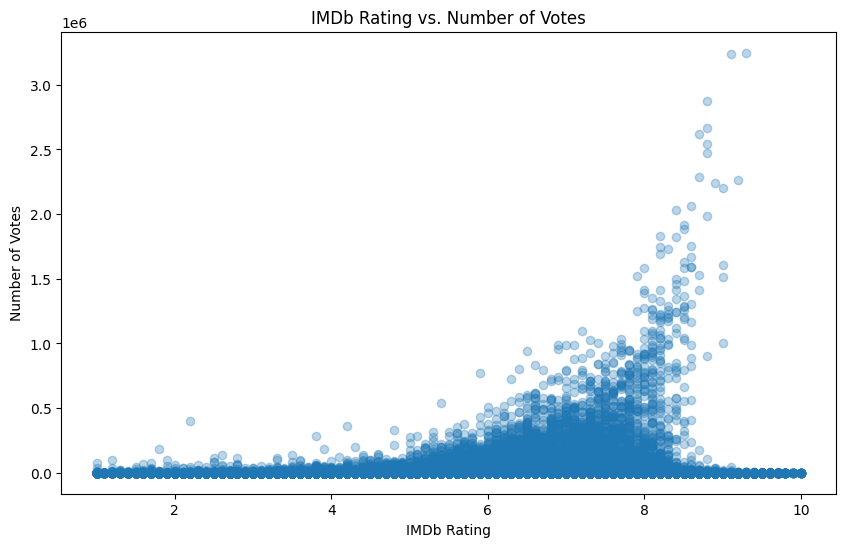

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    clean_movies["averageRating"],
    clean_movies["numVotes"],
    alpha=0.3
)

plt.xlabel("IMDb Rating")
plt.ylabel("Number of Votes")
plt.title("IMDb Rating vs. Number of Votes")

plt.show()

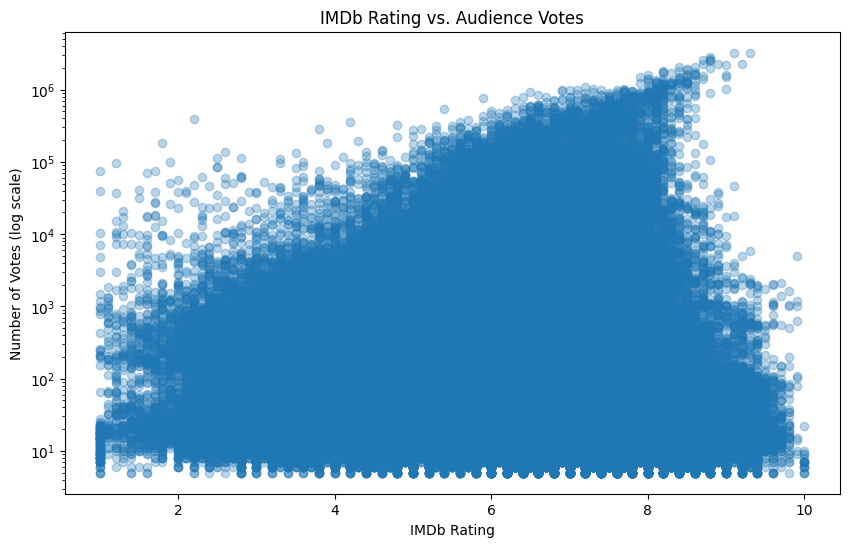

In [22]:
plt.figure(figsize=(10, 6))

plt.scatter(
    clean_movies["averageRating"],
    clean_movies["numVotes"],
    alpha=0.3
)

plt.yscale("log")

plt.xlabel("IMDb Rating")
plt.ylabel("Number of Votes (log scale)")
plt.title("IMDb Rating vs. Audience Votes")

plt.show()

In [23]:
genre_movies = clean_movies.dropna(
    subset=["genres"]
).copy()

In [24]:
genre_movies["genres"] = genre_movies["genres"].str.split(",")

In [25]:
genre_movies = genre_movies.explode("genres")

In [26]:
genre_votes = (
    genre_movies
    .groupby("genres")["numVotes"]
    .mean()
    .sort_values(ascending=False)
)

genre_votes

,numVotes
genres,
Sci-Fi,19677.495637
Adventure,16174.945641
Animation,12245.505649
Fantasy,11577.443324
Action,11019.586783
Mystery,10071.383844
Crime,8338.491619
Thriller,7562.620724
Biography,7428.517254


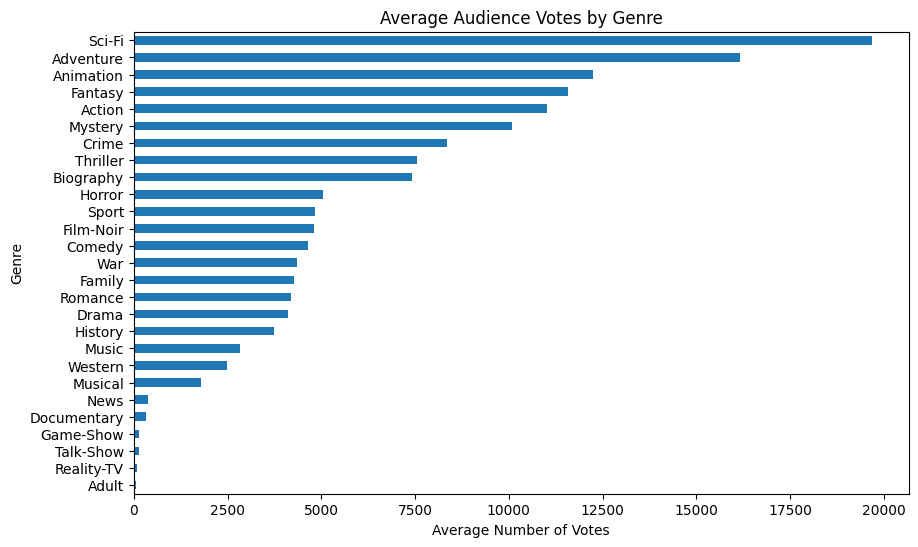

In [27]:
plt.figure(figsize=(10, 6))

genre_votes.sort_values().plot(kind="barh")

plt.xlabel("Average Number of Votes")
plt.ylabel("Genre")
plt.title("Average Audience Votes by Genre")

plt.show()

In [28]:
genre_ratings = (
    genre_movies
    .groupby("genres")["averageRating"]
    .mean()
    .sort_values(ascending=False)
)

genre_ratings

,averageRating
genres,
Game-Show,7.433333
News,7.180029
Documentary,7.172135
Biography,6.921867
Talk-Show,6.833333
Music,6.808470
History,6.764479
Sport,6.640278
Film-Noir,6.463014


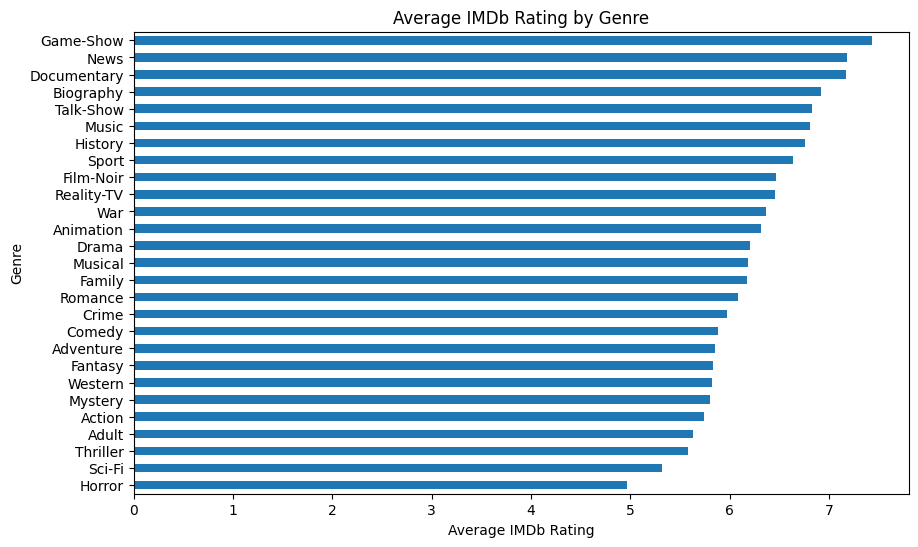

In [29]:
plt.figure(figsize=(10, 6))

genre_ratings.sort_values().plot(kind="barh")

plt.xlabel("Average IMDb Rating")
plt.ylabel("Genre")
plt.title("Average IMDb Rating by Genre")

plt.show()

In [30]:
runtime_movies = clean_movies.dropna(
    subset=["startYear", "runtimeMinutes"]
).copy()

In [31]:
runtime_by_year = (
    runtime_movies
    .groupby("startYear")["runtimeMinutes"]
    .mean()
)

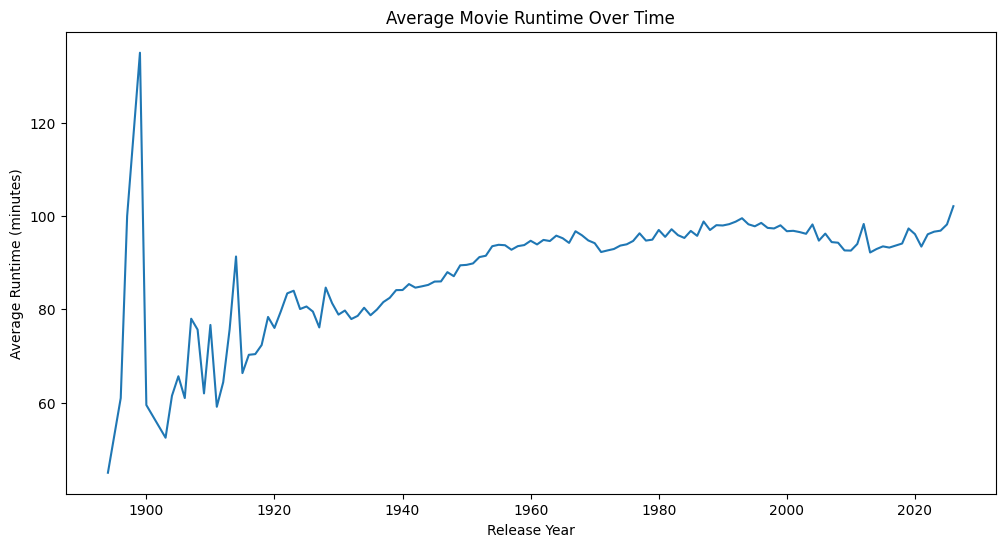

In [32]:
plt.figure(figsize=(12, 6))

plt.plot(
    runtime_by_year.index,
    runtime_by_year.values
)

plt.xlabel("Release Year")
plt.ylabel("Average Runtime (minutes)")
plt.title("Average Movie Runtime Over Time")

plt.show()

In [33]:
decade_movies = clean_movies.dropna(
    subset=["startYear"]
).copy()

decade_movies["decade"] = (
    (decade_movies["startYear"] // 10) * 10
)

In [34]:
decade_ratings = (
    decade_movies
    .groupby("decade")["averageRating"]
    .mean()
)

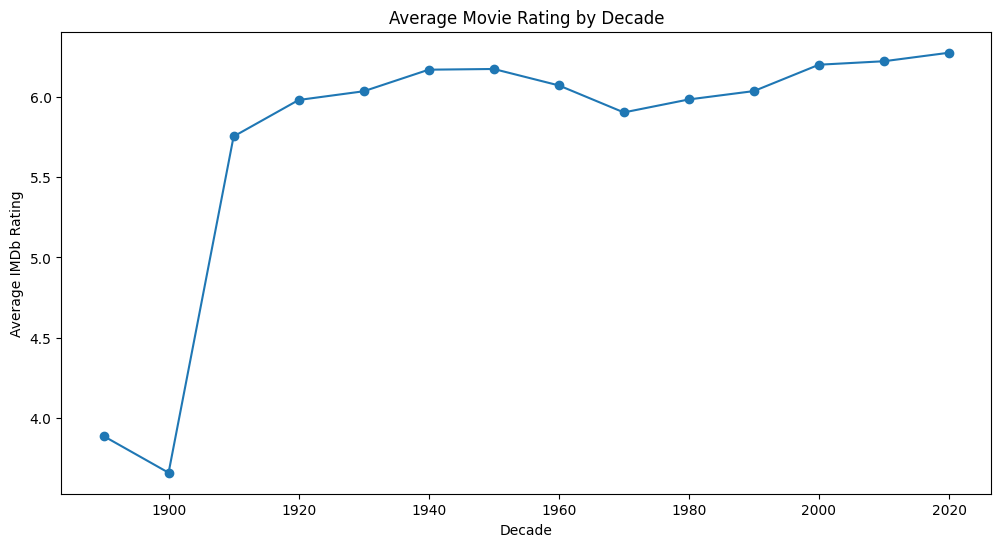

In [35]:
plt.figure(figsize=(12, 6))

plt.plot(
    decade_ratings.index,
    decade_ratings.values,
    marker="o"
)

plt.xlabel("Decade")
plt.ylabel("Average IMDb Rating")
plt.title("Average Movie Rating by Decade")

plt.show()

In [36]:
popular_movies = clean_movies[
    clean_movies["numVotes"] >= 1000
].copy()

In [37]:
print("Movies with at least 1,000 votes:", len(popular_movies))

Movies with at least 1,000 votes: 49223


In [38]:
popular_genres = popular_movies.dropna(
    subset=["genres"]
).copy()

popular_genres["genres"] = popular_genres["genres"].str.split(",")

popular_genres = popular_genres.explode("genres")

In [39]:
popular_genre_ratings = (
    popular_genres
    .groupby("genres")["averageRating"]
    .mean()
    .sort_values(ascending=False)
)

popular_genre_ratings

,averageRating
genres,
News,7.565517
Documentary,7.186925
Biography,6.899425
Film-Noir,6.848812
History,6.822950
Talk-Show,6.800000
War,6.773420
Music,6.706894
Animation,6.633764


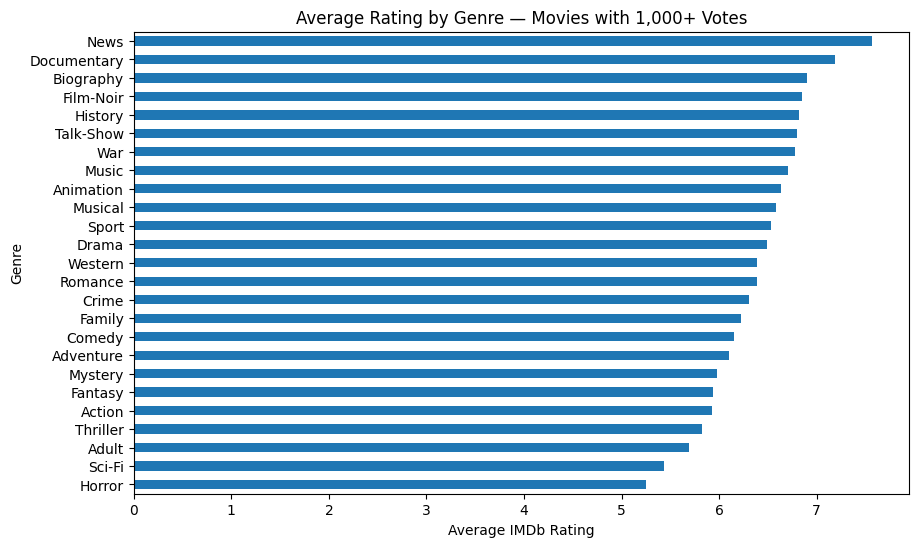

In [40]:
plt.figure(figsize=(10, 6))

popular_genre_ratings.sort_values().plot(kind="barh")

plt.xlabel("Average IMDb Rating")
plt.ylabel("Genre")
plt.title("Average Rating by Genre — Movies with 1,000+ Votes")

plt.show()

In [41]:
popular_genre_votes = (
    popular_genres
    .groupby("genres")["numVotes"]
    .mean()
    .sort_values(ascending=False)
)

popular_genre_votes

,numVotes
genres,
Sci-Fi,67597.880503
Adventure,63367.570115
Animation,48157.385609
Fantasy,46045.279113
Action,43457.191280
Mystery,32897.998327
Biography,31377.908359
Crime,30366.173860
Thriller,29424.410073


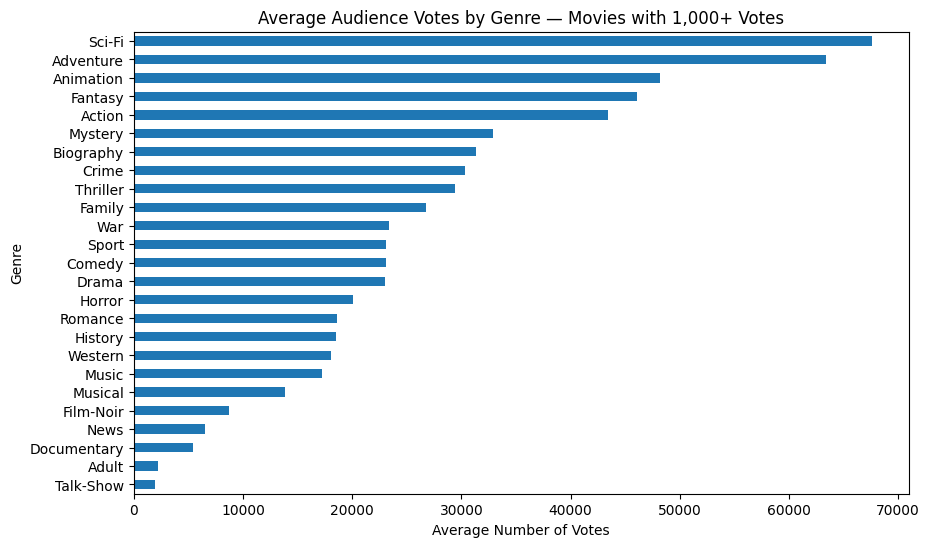

In [42]:
plt.figure(figsize=(10, 6))

popular_genre_votes.sort_values().plot(kind="barh")

plt.xlabel("Average Number of Votes")
plt.ylabel("Genre")
plt.title("Average Audience Votes by Genre — Movies with 1,000+ Votes")

plt.show()

In [43]:
clean_movies.to_csv(
    "/content/clean_movies.csv",
    index=False
)

In [44]:
popular_movies.to_csv(
    "/content/popular_movies_1000_votes.csv",
    index=False
)